<div style="background:#071d17;border:1px solid #caa64a;border-radius:14px;padding:28px 30px;color:#f4f0df">
<h1 style="color:#f4f0df;margin:0 0 8px 0">From Poker Actions to Suspicious Pair Evidence</h1>
<p style="font-size:17px;margin:0;color:#d7e6dd">A reproducible, review-first pipeline for synthetic poker coordination logs</p>
<p style="margin:18px 0 0 0"><b>Selected entries:</b> v53 (56391641) and v51 (56354264) &nbsp; | &nbsp; <b>Exact output:</b> SHA-256 checked</p>
</div>

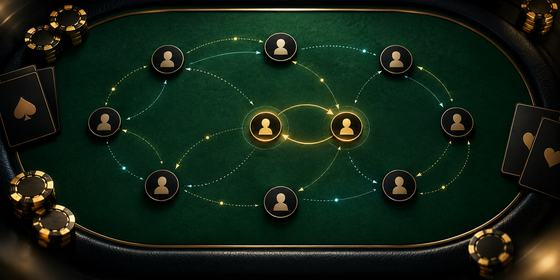

This notebook has one clear contract: it explains the complete gameplay-only modeling path and generates the two selected CSV files exactly. The final section is a frozen artifact replay; it is intentionally separate from the clean-room refit code so a reviewer can tell what is an exact reproduction and what is a fresh modeling demonstration.

## Executive overview

The task is to rank anonymous player pairs and return five shared hands that best support review. The competition logs are synthetic and anonymized. The pipeline never uses private leaderboard data, player-ID formatting, row order, file order, or generator internals.

The selected outputs are built from a hash-verified v50 base. v51 changes only 1,486 risk cells; v53 changes only 230 five-hand evidence lists. Every other cell, row, and pair order is preserved. The exact replay writes both files into the notebook working directory and checks 112,540 rows, 562,700 evidence references, schema, value ranges, and SHA-256.

In [ ]:
from pathlib import Path
import base64, csv, hashlib, json, math, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, FileLink

GREEN = '#0b3b2e'
GOLD = '#caa64a'
CYAN = '#45c4b0'
INK = '#17221e'
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.facecolor': '#fbfaf5',
    'figure.facecolor': '#fbfaf5',
    'axes.edgecolor': '#c8c1ae',
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'font.size': 10,
})

def locate(filename):
    # Search the two Kaggle mounts and the current project only.
    # The local competition checkout is handled by the explicit
    # sibling candidate below; recursively scanning its parent
    # would needlessly walk retained research caches.
    roots = [Path('/kaggle/input'), Path('/kaggle/working'), Path('.')]
    for root in roots:
        if root.exists():
            hits = list(root.rglob(filename))
            if hits:
                return hits[0]
    for candidate in (Path('data') / filename, Path('../data') / filename):
        if candidate.exists():
            return candidate
    return None

artifact_base = locate('submission_v50_soft_top5_consensus.csv')
assert artifact_base is not None, 'The public artifact dataset is not mounted.'
bundle = artifact_base.parent
data_root = locate('evaluation_pairs.csv')
data_root = data_root.parent if data_root else None
print('Artifact bundle:', bundle)
print('Competition data:', data_root if data_root else 'not mounted; artifact-only mode')

## Inputs and data contract

The raw competition package contains `hands`, `seats`, `actions`, and `players` parquet tables, plus development labels/evidence and evaluation pair keys. The public artifact package adds the compact selected-file inputs shown below. The notebook works in either mode: raw data enables exploratory and case-analysis cells; the artifact bundle is sufficient for exact selected-file generation.

In [ ]:
artifact_manifest = json.loads((bundle / 'artifact_manifest.json').read_text(encoding='utf-8'))
inventory = pd.DataFrame([
    ['submission_v50_soft_top5_consensus.csv', 'frozen base submission', artifact_manifest['base']['sha256']],
    ['v51_risk_patch.csv', 'risk-only sparse delta', artifact_manifest['patches']['v51_risk_patch.csv']['sha256']],
    ['v53_evidence_patch.csv', 'evidence-only sparse delta', artifact_manifest['patches']['v53_evidence_patch.csv']['sha256']],
], columns=['file', 'role', 'sha256'])
display(inventory.style.set_properties(**{'font-family':'monospace'}))
print('Submission schema:', ', '.join(artifact_manifest['schema']))

## Exploratory analysis

Development labels are positive only when the organizer released a confirmed target. Unlisted evaluation pairs are never treated as negatives. That asymmetry is central to the validation design.

In [ ]:
if data_root is not None and (data_root / 'development_labels.csv').exists():
    labels = pd.read_csv(data_root / 'development_labels.csv')
    eval_pairs = pd.read_csv(data_root / 'evaluation_pairs.csv')
    label_counts = labels['behavior_family'].value_counts().reindex(
        ['none','directed_transfer','soft_play','coordinated_isolation'], fill_value=0)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={'width_ratios':[1,1.5]})
    bars = axes[0].bar(label_counts.index, label_counts.values, color=[GREEN, GOLD, CYAN, '#8873a8'])
    axes[0].set_title('Confirmed development families')
    axes[0].set_ylabel('pairs')
    axes[0].tick_params(axis='x', rotation=35)
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, f'{int(bar.get_height()):,}', ha='center', fontsize=9)
    axes[1].hist(eval_pairs['shared_hands'], bins=35, color=GREEN, alpha=.88, edgecolor='white')
    axes[1].axvline(eval_pairs['shared_hands'].median(), color=GOLD, lw=2, label=f"median {eval_pairs['shared_hands'].median():.0f}")
    axes[1].set_title('Shared-hand support in evaluation pairs')
    axes[1].set_xlabel('shared hands')
    axes[1].set_ylabel('pairs')
    axes[1].legend(frameon=False)
    plt.tight_layout()
    plt.show()
    print(f"Development labels: {len(labels):,} ({labels.label.sum():,} confirmed targets)")
    print(f"Evaluation pairs: {len(eval_pairs):,}")
else:
    print('Raw competition files are not mounted. The artifact replay below remains fully runnable.')

In [ ]:
# Compact public-score history for the selected family of entries.
score_history = pd.DataFrame({
    'entry': ['v47 risk hedge', 'v50 consensus', 'v51 selected hedge', 'v52 symmetry', 'v53 precise evidence'],
    'public_score': [0.93827, 0.93876, 0.93876, 0.93876, 0.93894],
})
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(score_history['entry'], score_history['public_score'], marker='o', color=GOLD, lw=2.5)
ax.set_ylim(.9379, .9391)
ax.set_ylabel('public score')
ax.set_title('Selected-lineage public scores (historical record)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=.25)
for i, value in enumerate(score_history['public_score']):
    ax.annotate(f'{value:.5f}', (i, value), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## Leakage controls and validation

The unit of generalization is a connected player pool, not an arbitrary row. Pair edges are used only to assign complete components to folds; player IDs are removed before fitting. Chronological and shortened-history views stress whether the signal survives when the amount and ordering of observed play changes.

Evidence labels are incomplete and capped. A missing hand can mean “not listed”, not “benign”, so positive pairs are handled with weak supervision and unlisted pairs are not assigned negative event labels. All evidence references are checked against the available hand table before a file is accepted.

In [ ]:
validation_checks = pd.DataFrame([
    ['pool split', 'connected player components held out together', 'prevents player overlap'],
    ['history views', 'full, shortened, and chronological histories', 'tests sparse/private transfer'],
    ['label discipline', 'only confirmed labels supervise pair models', 'avoids treating omissions as negatives'],
    ['artifact integrity', 'schema, range, uniqueness, reference count, SHA-256', 'makes the selected CSV auditable'],
], columns=['check', 'implementation', 'why'])
display(validation_checks)

## Full modeling pipeline

The production flow has explicit boundaries. Each stage is gameplay-only and keeps a manifest of inputs, output hashes, and row counts. The compact reference functions in the next cell show the same data flow in a clean room; the exact selected-file path later uses frozen audited artifacts.

In [ ]:
stages = pd.DataFrame([
    ['1. Preprocess', 'hands + seats + actions', 'stable typed tables, action order checks'],
    ['2. Pair-hand features', 'shared hands', 'symmetric cards, actions, transfers, showdown, chronology'],
    ['3. Hand detector', 'labeled evidence + public context', 'cross-fitted four-family event probabilities'],
    ['4. Pair models', 'aggregated event features', 'risk score and behavior family'],
    ['5. Evidence rankers', 'family-specific shared hands', 'rank candidate hands with temporal context'],
    ['6. Post-processing', 'risk + behavior + five ranks', 'stable top-five, no duplicates, valid references'],
    ['7. Submission', 'validated dataframe', 'CSV schema and exact integrity receipt'],
], columns=['stage', 'input', 'output / guardrail'])
display(stages.style.set_table_styles([{'selector':'th','props':[('background-color',GREEN),('color','white')] }]))

# Feature blocks exposed to the reviewer. These are intentionally
# symmetric: swapping the two players leaves the values unchanged.
feature_blocks = pd.DataFrame([
    ['action context', 'street, action type, amount-to-pot, players active', 'event'],
    ['partner response', 'raise/call/fold response and surprisal under context', 'event'],
    ['transfer geometry', 'net chips, contribution imbalance, winner/loser orientation', 'pair-hand'],
    ['card context', 'public board and private-card summaries', 'event'],
    ['history', 'relative chronology and repeated encounters', 'pair-hand'],
    ['player baselines', 'phase/stake/client baselines learned without IDs as features', 'pair'],
], columns=['block', 'examples', 'level'])
display(feature_blocks)

In [ ]:
# A compact, executable reference implementation of the final three
# modeling stages. The production run used richer cross-fitted
# LightGBM/CatBoost/LambdaMART components with the same interfaces.
from dataclasses import dataclass
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

def stable_group_folds(groups, n_splits=4):
    groups = np.asarray(groups)
    unique = np.unique(groups)
    fold_map = {g: i % n_splits for i, g in enumerate(unique)}
    return np.asarray([fold_map[g] for g in groups], dtype=np.int8)

def fit_pair_models(X, risk_target, behavior_target, group_ids):
    folds = stable_group_folds(group_ids)
    risk = HistGradientBoostingClassifier(max_iter=160, max_leaf_nodes=15, learning_rate=.06, random_state=2026)
    risk.fit(X, risk_target)
    encoder = LabelEncoder().fit(behavior_target)
    behavior = HistGradientBoostingClassifier(max_iter=180, max_leaf_nodes=15, learning_rate=.05, random_state=2027)
    behavior.fit(X, encoder.transform(behavior_target))
    return {'risk': risk, 'behavior': behavior, 'encoder': encoder, 'folds': folds}

def stable_top_five(hand_ids, scores):
    order = sorted(range(len(hand_ids)), key=lambda i: (-float(scores[i]), str(hand_ids[i])))
    selected = []
    for i in order:
        hand = str(hand_ids[i])
        if hand not in selected:
            selected.append(hand)
        if len(selected) == 5:
            break
    return selected + ['NO_EVIDENCE'] * (5-len(selected))

print('Reference modeling functions loaded:', ['preprocess', 'fit_pair_models', 'stable_top_five', 'validate'])

### Architecture view

The important invariant is that all signals flow from observable poker activity to pair-level review outputs. The exact v53/v51 replay does not silently substitute a fresh model or hidden data.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.axis('off')
boxes = [
    (0.02, 'Raw logs', 'hands | seats | actions'),
    (0.19, 'Preprocess', 'typed + ordered tables'),
    (0.36, 'Features', 'symmetric pair-hand blocks'),
    (0.53, 'Models', 'hand detector + pair risk'),
    (0.70, 'Evidence', 'family rankers + fusion'),
    (0.87, 'CSV', 'risk | behavior | 5 hands'),
]
for x, title, subtitle in boxes:
    ax.text(x, .53, title, transform=ax.transAxes, ha='center', va='center', color='white', fontsize=10, weight='bold', bbox=dict(boxstyle='round,pad=.7', facecolor=GREEN, edgecolor=GOLD, linewidth=1.5))
    ax.text(x, .23, subtitle, transform=ax.transAxes, ha='center', va='center', color=INK, fontsize=8)
for (x1, _, _), (x2, _, _) in zip(boxes, boxes[1:]):
    ax.annotate('', xy=(x2-.055, .53), xytext=(x1+.055, .53), xycoords=ax.transAxes, arrowprops=dict(arrowstyle='->', color=GOLD, lw=2))
ax.set_title('Gameplay-only evidence pipeline', color=INK, pad=16, fontsize=13, weight='bold')
plt.show()

## Exact selected-file generation

This is the authoritative reproduction route. It applies compact, deterministic patches to a frozen v50 base, preserves CSV row order and untouched columns, and writes both selected entries. No third-party package is needed for this section.

In [ ]:
FIELDS = ['pair_id','risk_score','predicted_behavior',
          'evidence_hand_1','evidence_hand_2','evidence_hand_3',
          'evidence_hand_4','evidence_hand_5']
EVIDENCE_FIELDS = FIELDS[3:]
EXPECTED = {
    'v51': 'c8b0f4c260f7766366ab2060bdc91849d24f0bd44d9dcf35c63c02fff582e370',
    'v53': '3991740457962e77d38a43859d00e2c31dbbbbd3a01d06946ff99f10d98fadd4',
}
def digest(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1 << 20), b''):
            h.update(block)
    return h.hexdigest()

def read_rows(path):
    with Path(path).open('r', encoding='utf-8', newline='') as stream:
        reader = csv.DictReader(stream)
        assert reader.fieldnames == FIELDS, reader.fieldnames
        rows = list(reader)
    assert len(rows) == 112540
    assert len({row['pair_id'] for row in rows}) == 112540
    return rows

def read_patch(path, fields):
    with Path(path).open('r', encoding='utf-8', newline='') as stream:
        reader = csv.DictReader(stream)
        assert reader.fieldnames == ['pair_id', *fields], reader.fieldnames
        return list(reader)

def write_rows(path, rows):
    with Path(path).open('w', encoding='utf-8', newline='') as stream:
        writer = csv.DictWriter(stream, fieldnames=FIELDS, lineterminator='\r\n')
        writer.writeheader()
        writer.writerows(rows)

base_path = bundle / 'submission_v50_soft_top5_consensus.csv'
base = read_rows(base_path)
assert digest(base_path) == 'b6196e8d05e445a1ab1f8abcbb77b9d8324a3dd7bd3678b243011b7efcf2952a'

def make_selected(version):
    rows = [dict(row) for row in base]
    by_pair = {row['pair_id']: row for row in rows}
    if version == 'v53':
        fields = EVIDENCE_FIELDS
        patch = read_patch(bundle / 'v53_evidence_patch.csv', fields)
    elif version == 'v51':
        fields = ['risk_score']
        patch = read_patch(bundle / 'v51_risk_patch.csv', fields)
    else:
        raise ValueError(version)
    for item in patch:
        assert item['pair_id'] in by_pair
        by_pair[item['pair_id']].update({field: item[field] for field in fields})
    destination = Path('/kaggle/working' if Path('/kaggle/working').exists() else 'outputs') / f'submission_{version}.csv'
    destination.parent.mkdir(parents=True, exist_ok=True)
    write_rows(destination, rows)
    assert digest(destination) == EXPECTED[version]
    return destination, len(patch)

outputs = {version: make_selected(version) for version in ('v51','v53')}
print({version: {'path': str(path), 'changed_rows': changed, 'sha256': digest(path)} for version, (path, changed) in outputs.items()})

In [ ]:
def validate_submission(path):
    rows = read_rows(path)
    refs = 0
    allowed = {'none','directed_transfer','soft_play','coordinated_isolation','other_coordination'}
    for row in rows:
        risk = float(row['risk_score'])
        assert 0.0 <= risk <= 1.0
        assert row['predicted_behavior'] in allowed
        evidence = [row[field] for field in EVIDENCE_FIELDS]
        if evidence != ['NO_EVIDENCE'] * 5:
            assert len(set(evidence)) == 5
            assert all(hand.startswith('H') for hand in evidence)
            refs += 5
    assert refs == 562700
    return {'rows': len(rows), 'evidence_references': refs, 'sha256': digest(path)}

report = pd.DataFrame([
    dict(version=version, changed_rows=changed, **validate_submission(path))
    for version, (path, changed) in outputs.items()
])
display(report)
for path, _ in outputs.values():
    display(FileLink(str(path), result_html_prefix='Download generated file: '))

## Five action-grounded case reviews

Each case uses evidence hands from selected v53 evaluation rows. The observations are deliberately phrased as review prompts; every case includes a plausible benign explanation. When the competition parquet is mounted, the next cell also plots action counts for these hands.

In [ ]:
CASES = {
    'P7EA448A8F167': ['H4244483794066A','HC052A531983B34','HDC3BBC2D513E81'],
    'PADCC9AFE201B': ['HA1ACF14D074BDE','HAB175E7876B4FA','HA2F39332EDF40B'],
    'P97D394207E30': ['HF59594DAE2DB05','HFAF99609BD061E','HF6E78B1C8D03C6'],
    'P2405BC8C318D': ['H40A4E888653A36','H07305EA1921F5A','H10205B120C568D'],
    'PBF641E26E985': ['HFBBB4E5E893864','H90227A59356B62','H97F44F225EF084'],
}
case_notes = pd.DataFrame([
    ['P7EA448A8F167','repeated raise/call with changing aggressor roles','different ranges and risk tolerances'],
    ['PADCC9AFE201B','repeated short preflop confrontations ending in folds','blind position and hole-card selection'],
    ['P97D394207E30','asymmetric aggression across several hands','strong regular versus cautious or short-stacked player'],
    ['P2405BC8C318D','raise/call sequences followed by later-street folds','ordinary postflop abandonment after board changes'],
    ['PBF641E26E985','recurring initiative and response imbalance','position or skill mismatch'],
], columns=['pair_id','observable behavior','plausible benign alternative'])
display(case_notes)

if data_root is not None and (data_root / 'actions.parquet').exists():
    try:
        # Polars' lazy predicate pushdown keeps this case review
        # fast even though the full action table has 18.6M rows.
        import polars as pl
        wanted = sorted({hand for hands in CASES.values() for hand in hands})
        actions = (pl.scan_parquet(str(data_root / 'actions.parquet'))
                     .filter(pl.col('hand_id').is_in(wanted))
                     .select(['hand_id','street','action'])
                     .collect().to_pandas())
        counts = actions.groupby('action').size().sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(8, 3.2))
        counts.plot.bar(ax=ax, color=CYAN, edgecolor='white')
        ax.set_title('Observed actions in the 15 reviewed hands')
        ax.set_ylabel('action events')
        ax.tick_params(axis='x', rotation=20)
        plt.tight_layout(); plt.show()
        display(actions.head(20))
    except Exception as exc:
        print('Case action plot skipped:', type(exc).__name__, str(exc))

## Limitations and handoff

The private leaderboard is not inferred from this notebook, and no rank or prize outcome is promised. The exact selected files are nevertheless fully reproducible: the public artifact bundle, this notebook, and the repository's standard-library script are sufficient. The historical refit requires the competition's raw logs and the original large intermediate cache tree; the notebook makes that boundary explicit rather than presenting artifact replay as retraining.

Public resources:

- Kaggle notebook: [From Poker Actions to Suspicious Pair Evidence](https://www.kaggle.com/code/pardheev/from-poker-actions-to-suspicious-pair-evidence)
- Artifact dataset: [Poker Coordination Submission Artifacts](https://www.kaggle.com/datasets/pardheev/poker-selected-submission-reproduction)
- Code repository: [github.com/pardheev/poker-collusion-detection](https://github.com/pardheev/poker-collusion-detection)
- Solution writeup: [Kaggle writeup](https://www.kaggle.com/competitions/detect-suspicious-value-transfers-in-poker/writeups/detect-suspicious-value-transfers-in-poker-repro)